# Day 6 - Threshold Analysis & Class-Imbalance Investigation

## Objective

The objective of Day 6 is to investigate whether changing the classification threshold or handling class imbalance can improve anomaly detection performance compared with the Day 5 Logistic Regression baseline.

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "AliMaatouk/TelecomTS",
    data_files={"full": "**/chunked.jsonl"}
)

data = dataset["full"]

print("Number of samples:", len(data))

README.md:   0%|          | 0.00/6.02k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/33 [00:00<?, ?it/s]

chunked.jsonl:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

chunked.jsonl:   0%|          | 0.00/3.07M [00:00<?, ?B/s]

...

normal/stationary/Zone_C/no_congestion/T(…): downloading bytes:           |  0.00B            

normal/stationary/Zone_C/no_congestion/Y(…): reconstructing file:   0%|          |  0.00B / 96.1MB            

normal/stationary/Zone_C/no_congestion/Y(…): downloading bytes:           |  0.00B            

Generating full split: 0 examples [00:00, ? examples/s]

Number of samples: 32000


In [2]:
numeric_kpis = [
    "RSRP",
    "DL_BLER",
    "DL_MCS",
    "UL_BLER",
    "UL_MCS",
    "UL_NPRB",
    "UL_SNR",
    "TX_Bytes",
    "RX_Bytes",
    "Estimated_UL_Buffer",
    "PRBs_DL_Current",
    "PRBs_UL_Current",
    "PRB_Utilization_DL",
    "PRB_Utilization_UL",
    "UL_NumberOfPackets",
    "DL_NumberOfPackets"
]

print("Number of numerical KPIs:", len(numeric_kpis))

Number of numerical KPIs: 16


In [3]:
import numpy as np
import pandas as pd

In [4]:
def extract_features(sample):
    features = {}

    for kpi in numeric_kpis:
        values = np.array(sample["KPIs"][kpi])

        features[f"{kpi}_mean"] = values.mean()
        features[f"{kpi}_std"] = values.std()
        features[f"{kpi}_min"] = values.min()
        features[f"{kpi}_max"] = values.max()

    return features

In [5]:
rows = []

for sample in data:
    features = extract_features(sample)

    label = 1 if sample["labels"]["anomaly_present"] == "Yes" else 0

    features["target"] = label

    rows.append(features)

df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

Dataset shape: (32000, 65)


In [6]:
X = df.drop("target", axis=1)
y = df["target"]

print("X:", X.shape)
print("y:", y.shape)

X: (32000, 64)
y: (32000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25600
Testing samples: 6400


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (25600, 64)
Testing shape: (6400, 64)


In [9]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

print("Baseline model trained.")

Baseline model trained.


In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:
    predictions = (baseline_prob >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.2,0.767790,0.829960,0.797665
1,0.3,0.867257,0.793522,0.828753
2,0.4,0.913462,0.769231,0.835165
3,0.5,0.953125,0.740891,0.833713
4,0.6,0.967213,0.716599,0.823256
5,0.7,0.970930,0.676113,0.797136
6,0.8,0.980769,0.619433,0.759305


In [12]:
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold)

Best threshold based on F1:
threshold    0.400000
precision    0.913462
recall       0.769231
f1           0.835165
Name: 2, dtype: float64


In [13]:
baseline_pred = (baseline_prob >= 0.50).astype(int)

best_threshold_value = best_threshold["threshold"]

best_threshold_pred = (
    baseline_prob >= best_threshold_value
).astype(int)

threshold_comparison = pd.DataFrame({
    "Model": [
        "Day 5 Baseline (0.50)",
        f"Best Threshold ({best_threshold_value:.2f})"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, best_threshold_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, best_threshold_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, best_threshold_pred)
    ]
})

threshold_comparison

,Model,Precision,Recall,F1
0,Day 5 Baseline (0.50),0.953125,0.740891,0.833713
1,Best Threshold (0.40),0.913462,0.769231,0.835165


In [14]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)

balanced_prob = balanced_model.predict_proba(
    X_test_scaled
)[:, 1]

balanced_pred = (
    balanced_prob >= 0.50
).astype(int)

In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        balanced_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      6153
           1       0.47      0.93      0.62       247

    accuracy                           0.96      6400
   macro avg       0.73      0.94      0.80      6400
weighted avg       0.98      0.96      0.96      6400



In [16]:
balanced_precision = precision_score(
    y_test,
    balanced_pred
)

balanced_recall = recall_score(
    y_test,
    balanced_pred
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred
)

print("Balanced Logistic Regression")
print("Precision:", balanced_precision)
print("Recall:", balanced_recall)
print("F1:", balanced_f1)

Balanced Logistic Regression
Precision: 0.46938775510204084
Recall: 0.9311740890688259
F1: 0.6241519674355496


In [17]:
from sklearn.metrics import roc_auc_score

baseline_pred = (
    baseline_prob >= 0.50
).astype(int)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, balanced_prob)
    ]
})

comparison

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.953125,0.740891,0.833713,0.978539
1,Logistic Regression (Balanced),0.469388,0.931174,0.624152,0.984076


In [18]:
from sklearn.metrics import confusion_matrix

balanced_cm = confusion_matrix(
    y_test,
    balanced_pred
)

print(balanced_cm)

[[5893  260]
 [  17  230]]


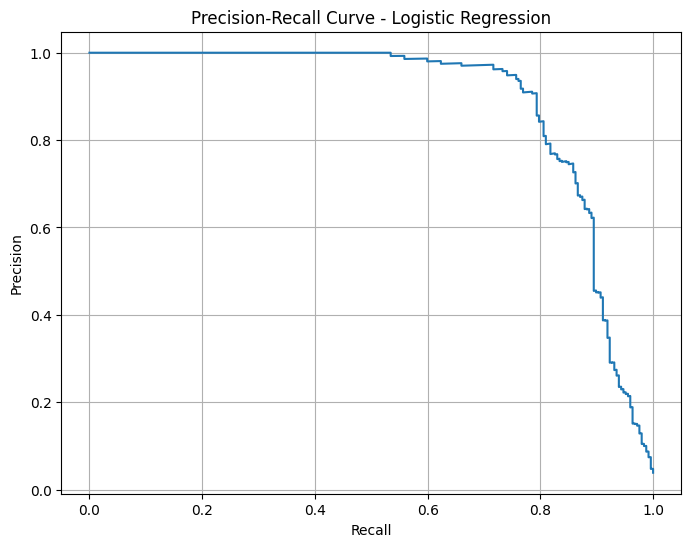

In [19]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    baseline_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.grid()

plt.show()

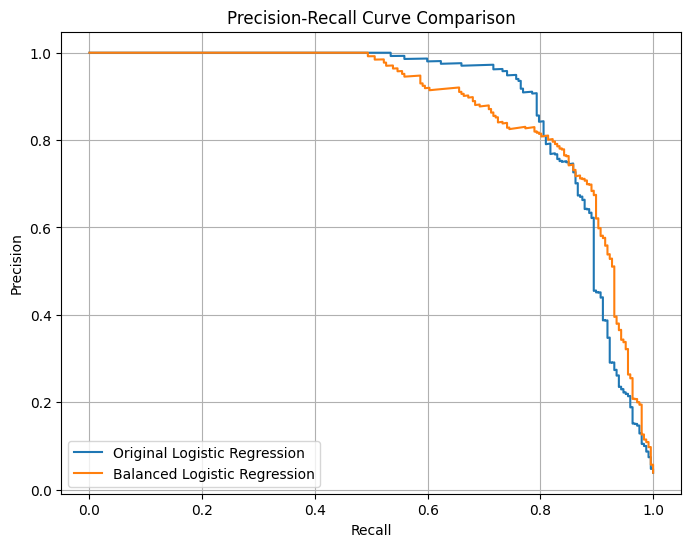

In [20]:
baseline_precision_curve, baseline_recall_curve, _ = precision_recall_curve(
    y_test,
    baseline_prob
)

balanced_precision_curve, balanced_recall_curve, _ = precision_recall_curve(
    y_test,
    balanced_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_recall_curve,
    baseline_precision_curve,
    label="Original Logistic Regression"
)

plt.plot(
    balanced_recall_curve,
    balanced_precision_curve,
    label="Balanced Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")

plt.legend()
plt.grid()

plt.show()

In [21]:
final_comparison = pd.DataFrame({
    "Experiment": [
        "Day 5 Baseline",
        "Best Threshold",
        "Balanced Logistic Regression"
    ],
    "Threshold": [
        0.50,
        best_threshold_value,
        0.50
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, best_threshold_pred),
        precision_score(y_test, balanced_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, best_threshold_pred),
        recall_score(y_test, balanced_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, best_threshold_pred),
        f1_score(y_test, balanced_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, balanced_prob)
    ]
})

final_comparisonfinal_comparison = pd.DataFrame({
    "Experiment": [
        "Day 5 Baseline",
        "Best Threshold",
        "Balanced Logistic Regression"
    ],
    "Threshold": [
        0.50,
        best_threshold_value,
        0.50
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, best_threshold_pred),
        precision_score(y_test, balanced_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, best_threshold_pred),
        recall_score(y_test, balanced_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, best_threshold_pred),
        f1_score(y_test, balanced_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, baseline_prob),
        roc_auc_score(y_test, balanced_prob)
    ]
})

final_comparison

,Experiment,Threshold,Precision,Recall,F1,ROC-AUC
0,Day 5 Baseline,0.5,0.953125,0.740891,0.833713,0.978539
1,Best Threshold,0.4,0.913462,0.769231,0.835165,0.978539
2,Balanced Logistic Regression,0.5,0.469388,0.931174,0.624152,0.984076


In [22]:
from sklearn.metrics import confusion_matrix

experiments = {
    "Day 5 Baseline": baseline_pred,
    "Best Threshold": best_threshold_pred,
    "Balanced Logistic Regression": balanced_pred
}

error_summary = []

for name, predictions in experiments.items():
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    error_summary.append({
        "Experiment": name,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn
    })

error_summary = pd.DataFrame(error_summary)

error_summary

,Experiment,False Positives,False Negatives,True Positives,True Negatives
0,Day 5 Baseline,9,64,183,6144
1,Best Threshold,18,57,190,6135
2,Balanced Logistic Regression,260,17,230,5893


## Day 6 Research Question

Does changing the decision threshold or using class-weighted Logistic Regression provide a better balance between anomaly recall and false-positive rate than the original Logistic Regression baseline?

The experiments compare:
- Different classification thresholds
- Original Logistic Regression
- Balanced Logistic Regression
- Precision
- Recall
- F1-score
- ROC-AUC
- False positives
- False negatives